# Iris Flower Classification
**Task 1 - OASIS INFOBYTE Data Science Internship**

Classify iris flowers into three species: *setosa*, *versicolor*, and *virginica* based on sepal and petal measurements.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style('whitegrid')
%matplotlib inline

---
## 1. Load the Dataset

In [2]:
df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


The dataset can also be loaded directly from Scikit-learn's built-in `load_iris()`:

In [3]:
from sklearn.datasets import load_iris

iris = load_iris()
df2 = pd.DataFrame(iris.data, columns=iris.feature_names)
df2['Species'] = iris.target_names[iris.target]
df2.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [5]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [6]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

---
## 2. Exploratory Data Analysis

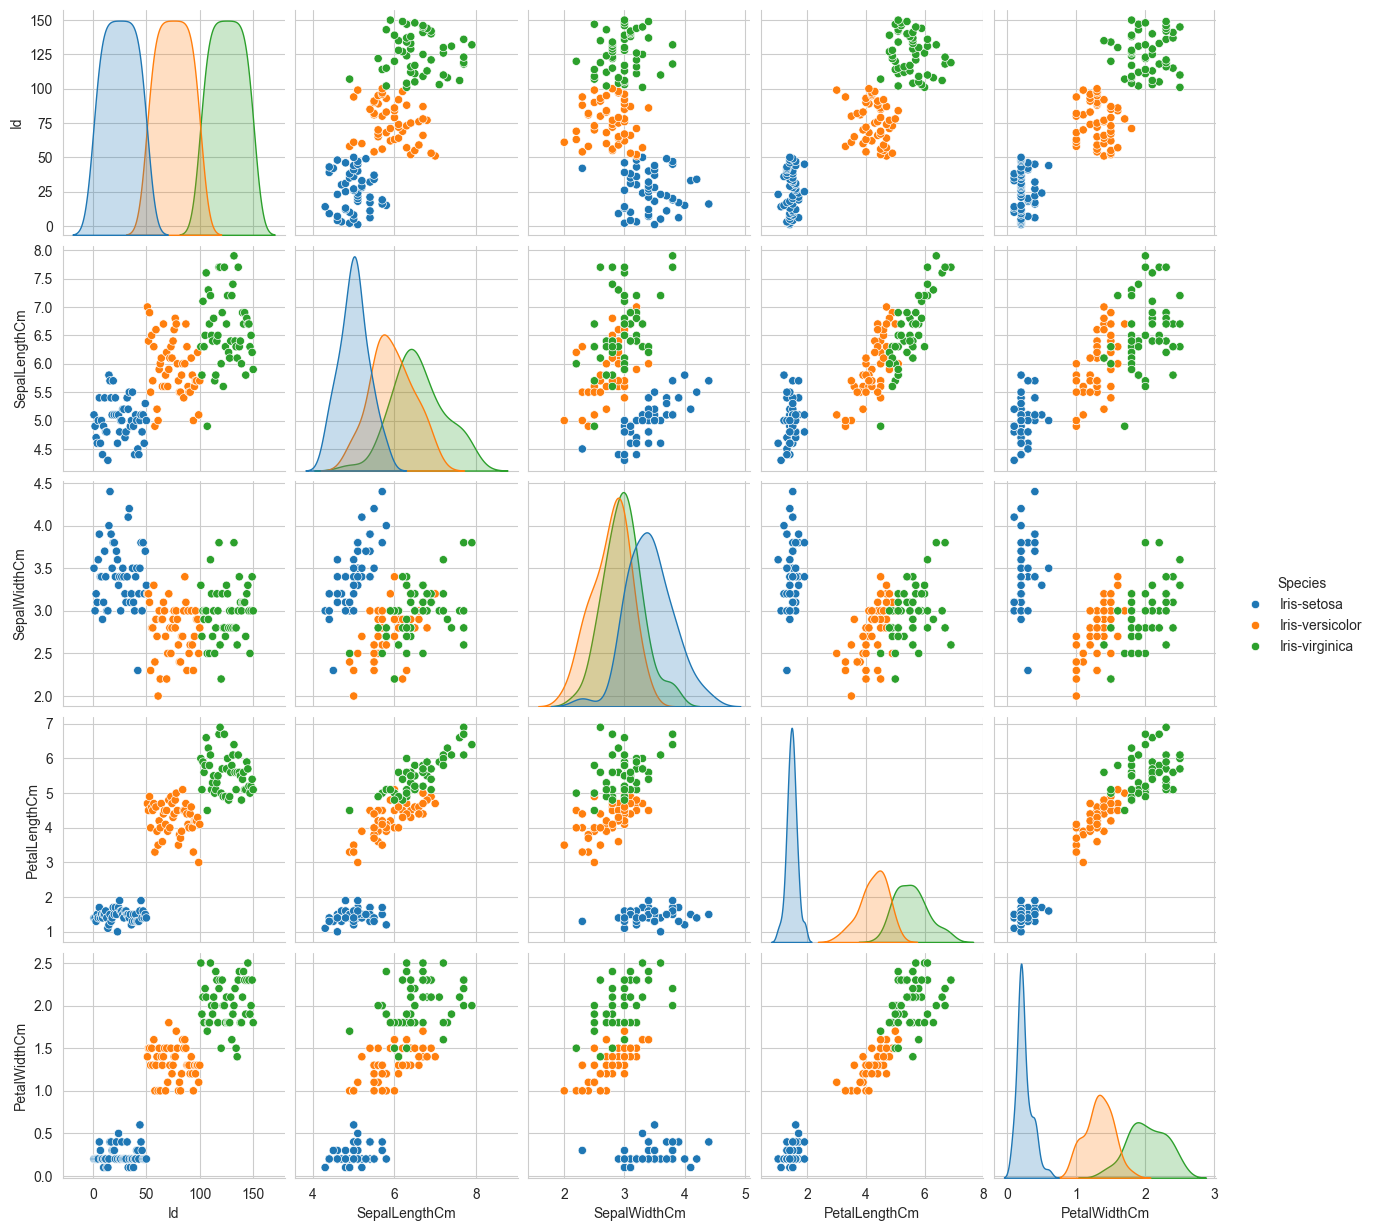

In [7]:
sns.pairplot(df, hue='Species', diag_kind='kde')
plt.show()

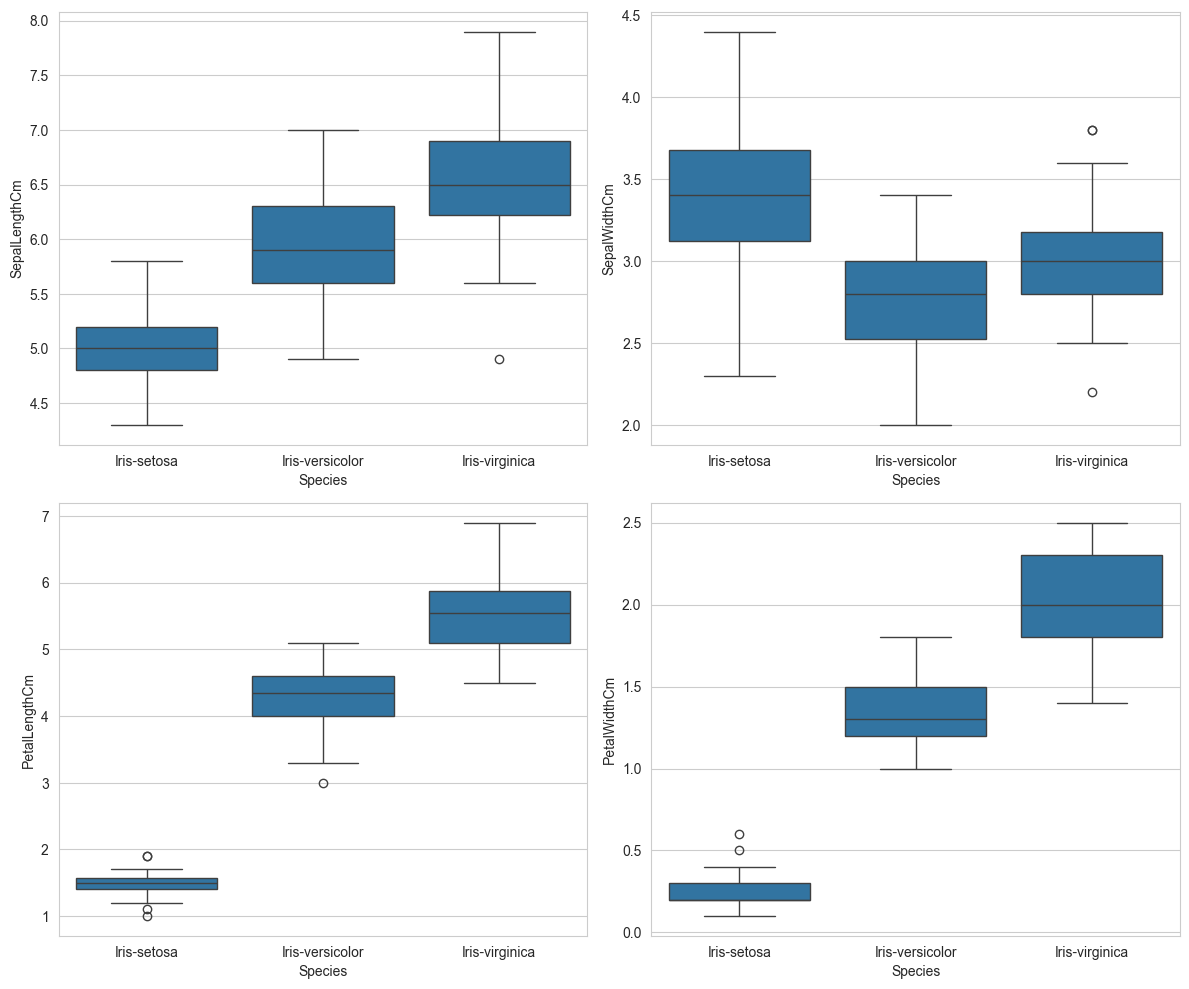

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
for ax, feat in zip(axes.ravel(), features):
    sns.boxplot(data=df, x='Species', y=feat, ax=ax)
plt.tight_layout()
plt.show()

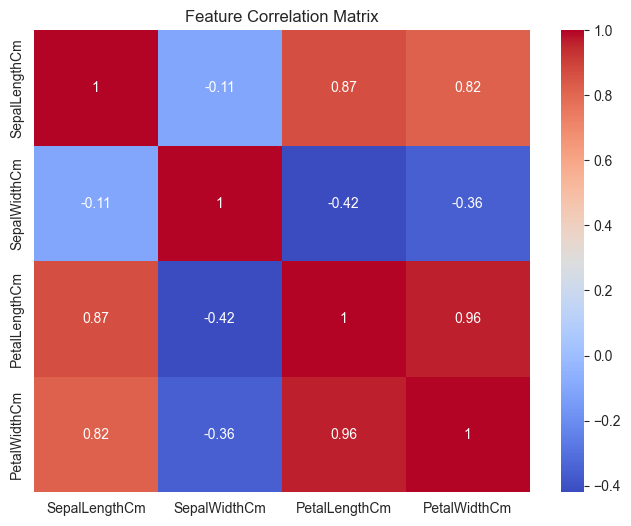

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(columns=['Id', 'Species']).corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

---
## 3. Data Preprocessing

In [10]:
X = df.drop(columns=['Id', 'Species'])
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')

Training samples: 120
Test samples: 30


---
## 4. Model Training & Evaluation

In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'\n{'='*40}')
    print(f'{name}')
    print(f'Accuracy: {acc:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred))
    print(f'Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))


Logistic Regression
Accuracy: 0.9333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

K-Nearest Neighbors
Accuracy: 0.9333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30

Confusion Matrix:

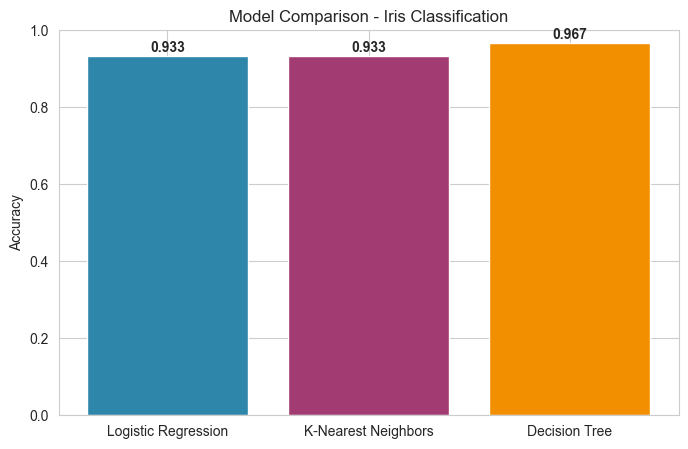

In [12]:
plt.figure(figsize=(8, 5))
colors = ['#2E86AB', '#A23B72', '#F18F01']
bars = plt.bar(results.keys(), results.values(), color=colors)
plt.ylabel('Accuracy')
plt.title('Model Comparison - Iris Classification')
plt.ylim(0, 1)
for bar, acc in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', fontweight='bold')
plt.show()

---
## 5. Make a Prediction

In [13]:
best_model = max(results, key=results.get)
model = models[best_model]
print(f'Best model: {best_model} ({results[best_model]:.2%} accuracy)')

import pandas as pd
new_sample = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=X.columns)
new_sample_scaled = scaler.transform(new_sample)
prediction = model.predict(new_sample_scaled)
print(f'Sample {new_sample.iloc[0].tolist()} -> Predicted: {prediction[0]}')

Best model: Decision Tree (96.67% accuracy)
Sample [5.1, 3.5, 1.4, 0.2] -> Predicted: Iris-setosa
